# Diamond Price Prediction

### Problem Statement
Predict the price of a diamond based on its physical attributes such as carat, cut, color, clarity, depth, table, and dimensions (x, y, z).

- **Target variable:** `price` (in USD)
- **Input features:** 9 physical and quality characteristics
- **Dataset:** `datasets/diamonds.csv`

# 1. Dataset Loading and Initial Audit

In this step, we load the raw dataset and inspect its basic structure:
- Check rows, columns, and data types
- Check for missing values and duplicate rows
- Inspect summary statistics and the distribution of the target variable (`price`)

## 1.1 Importing Required Libraries
Importing essential Python libraries for numerical computing, data analysis, and visualization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics for clean, publication-ready figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 110

print("Environment and libraries initialized successfully.")

Environment and libraries initialized successfully.


## 1.2 Loading the Dataset
We load `datasets/diamonds.csv` using pandas.

In [2]:
# Resolve dataset path portably
data_path = os.path.join("..", "datasets", "diamonds.csv") if os.path.exists(os.path.join("..", "datasets", "diamonds.csv")) else os.path.join("datasets", "diamonds.csv")
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded from: {data_path}")
print(f"Exact Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset successfully loaded from: datasets\diamonds.csv
Exact Shape: 53,940 rows x 10 columns


## 1.3 Previewing the Data
Checking the first 5 and last 5 rows to confirm the data loaded correctly.

In [3]:
print("First 5 rows of the dataset:")
display(df.head())

print()
print("Last 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335



Last 5 rows of the dataset:


,carat,cut,color,clarity,depth,table,x,y,z,price
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757
53939,0.75,Ideal,D,SI2,62.2,55.0,5.83,5.87,3.64,2757


## 1.4 Checking Data Types, Missing Values, and Duplicates
Summary table showing data types, null values, and unique counts for every column.

In [4]:
# Dataset audit table
audit_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Count': df.nunique()
}).reset_index(drop=True)

display(audit_df)

# Duplicate row check
dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100
print()
print(f"Exact Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

,Column Name,Data Type,Missing Count,Missing (%),Unique Count
0,carat,float64,0,0.0,273
1,cut,str,0,0.0,5
2,color,str,0,0.0,7
3,clarity,str,0,0.0,8
4,depth,float64,0,0.0,184
5,table,float64,0,0.0,127
6,x,float64,0,0.0,554
7,y,float64,0,0.0,552
8,z,float64,0,0.0,375
9,price,int64,0,0.0,11602



Exact Duplicate Rows: 146 (0.27% of dataset)


## 1.5 Target Variable (`price`) Statistics
Basic statistical summary of diamond prices.

In [5]:
price = df['price']

target_summary = pd.DataFrame({
    'Metric': [
        'Total Count', 'Minimum Price', 'Maximum Price', 'Mean Price', 
        'Median Price', 'Standard Deviation', 'Q1 (25th percentile)', 
        'Q3 (75th percentile)', 'IQR (Interquartile Range)', 
        'Skewness', 'Kurtosis', 'Unique Target Values'
    ],
    'Value': [
        f"{len(price):,}",
        f"${price.min():,}",
        f"${price.max():,}",
        f"${price.mean():,.2f}",
        f"${price.median():,.2f}",
        f"${price.std():,.2f}",
        f"${price.quantile(0.25):,.2f}",
        f"${price.quantile(0.75):,.2f}",
        f"${(price.quantile(0.75) - price.quantile(0.25)):,.2f}",
        f"{price.skew():.4f}",
        f"{price.kurtosis():.4f}",
        f"{price.nunique():,}"
    ]
})

display(target_summary)

,Metric,Value
0,Total Count,"53,940"
1,Minimum Price,$326
2,Maximum Price,"$18,823"
3,Mean Price,"$3,932.80"
4,Median Price,"$2,401.00"
5,Standard Deviation,"$3,989.44"
6,Q1 (25th percentile),$950.00
7,Q3 (75th percentile),"$5,324.25"
8,IQR (Interquartile Range),"$4,374.25"
9,Skewness,1.6184


## 1.6 Target Distribution Plot
Histogram and KDE of diamond prices with mean and median lines.

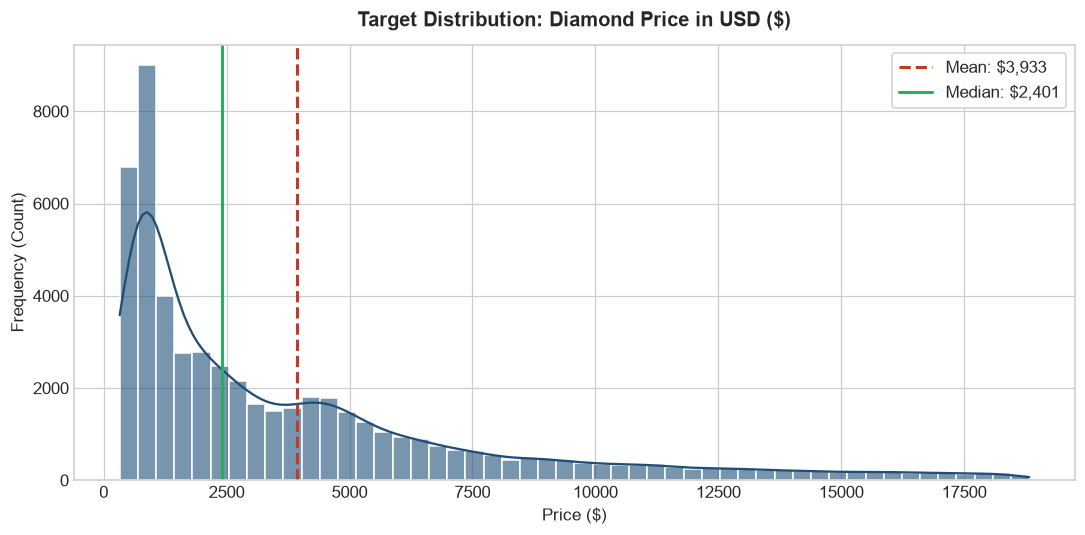

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['price'], bins=50, kde=True, color='#1f4e79', edgecolor='white', alpha=0.6, ax=ax)

# Reference vertical lines for Mean and Median
ax.axvline(price.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f"Mean: ${price.mean():,.0f}")
ax.axvline(price.median(), color='#27ae60', linestyle='-', linewidth=2, label=f"Median: ${price.median():,.0f}")

ax.set_title("Target Distribution: Diamond Price in USD ($)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Price ($)", fontsize=11)
ax.set_ylabel("Frequency (Count)", fontsize=11)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

**Observations on Price:**
- The price distribution is right-skewed. Most diamonds in this dataset are under $2,500 (median is $2,401, while mean is $3,933).
- There is a long right tail with high-value diamonds reaching up to $18,823.

## 1.7 Feature Overview

| Feature | Type | Description |
| :--- | :--- | :--- |
| `carat` | Numerical | Weight of the diamond (1 carat = 0.2 g). Main driver of price. |
| `cut` | Categorical | Cut quality: Fair, Good, Very Good, Premium, Ideal. |
| `color` | Categorical | Diamond color rating from J (worst) to D (best). |
| `clarity` | Categorical | How clear the diamond is: I1 (worst) to IF (internally flawless). |
| `depth` | Numerical | Total depth percentage = 2 * z / (x + y) * 100. |
| `table` | Numerical | Width of diamond's top facet as a percentage of widest point. |
| `x` | Numerical | Length in mm. |
| `y` | Numerical | Width in mm. |
| `z` | Numerical | Depth in mm. |

# 2. EDA

Now we explore patterns and relationships in the data before any preprocessing:
- Distribution of individual numerical and categorical features
- Correlation between numerical features and price
- Scatter plots of key features against price
- Boxplots of price across cut, color, and clarity
- Boxplots to spot potential outliers

## 2.1 Numerical Feature Distributions
Histograms for all numerical features to see their spread and shapes.

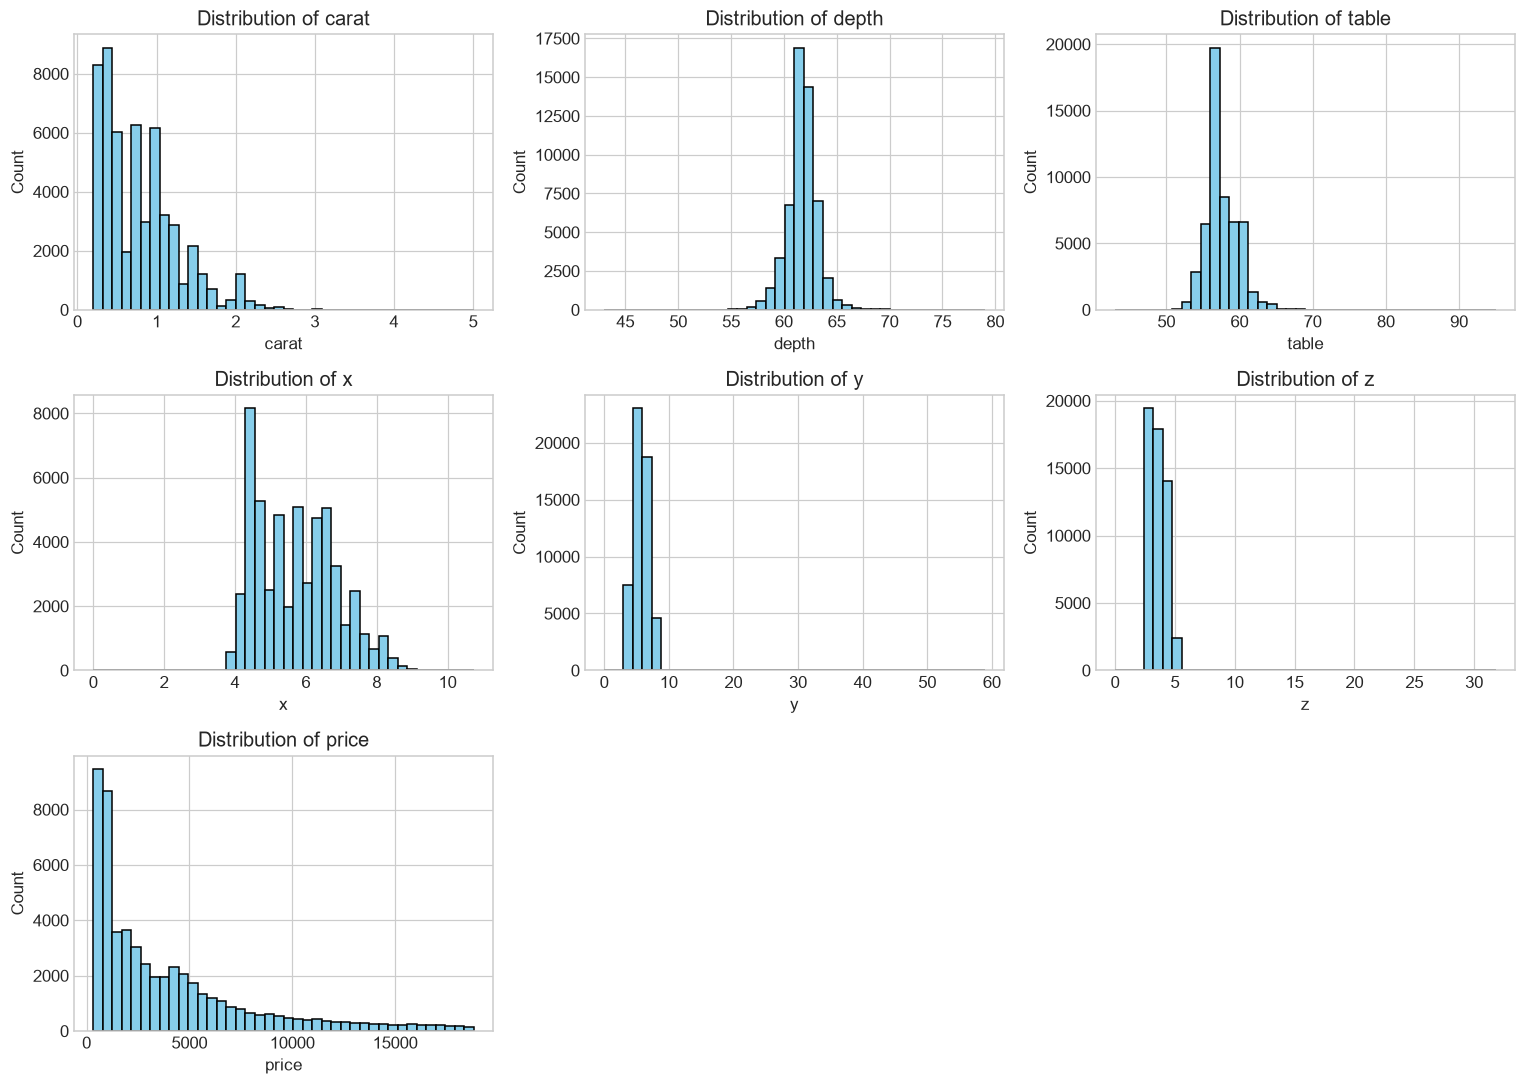

In [7]:
# Numerical feature histograms
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=40, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots
fig.delaxes(axes[7])
fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

**Observations on Numerical Features:**
- `carat` and `price` are both strongly right-skewed. Most diamonds are under 1 carat and under $3,000.
- `depth` and `table` have symmetric bell-shaped distributions centered around typical cut proportions (~61-62% depth, ~57-58% table).
- `x`, `y`, and `z` have similar shapes to carat, but we notice a few values at 0 and some extreme high values that look like data entry errors.

## 2.2 Categorical Feature Distributions
Bar plots showing the count of diamonds in each category.

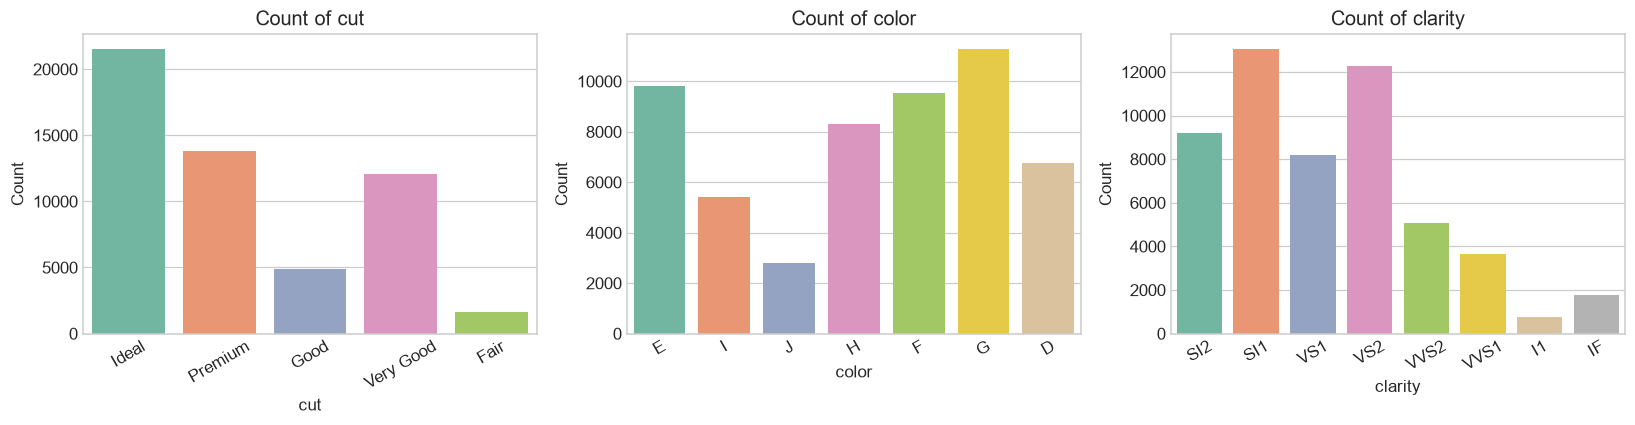

In [8]:
# Categorical feature count plots
categorical_cols = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue=col, palette='Set2', legend=False)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations on Categorical Features:**
- `cut`: Most diamonds have `Ideal` or `Premium` cuts. `Fair` is the least common.
- `color`: Most common colors are `G`, `E`, and `F`. Lower color grades like `J` are less frequent.
- `clarity`: `SI1`, `VS2`, and `SI2` are the most frequent grades. Flawless (`IF`) and included (`I1`) diamonds are relatively rare.

## 2.3 Correlation Heatmap
Checking linear correlations between numerical variables and price.

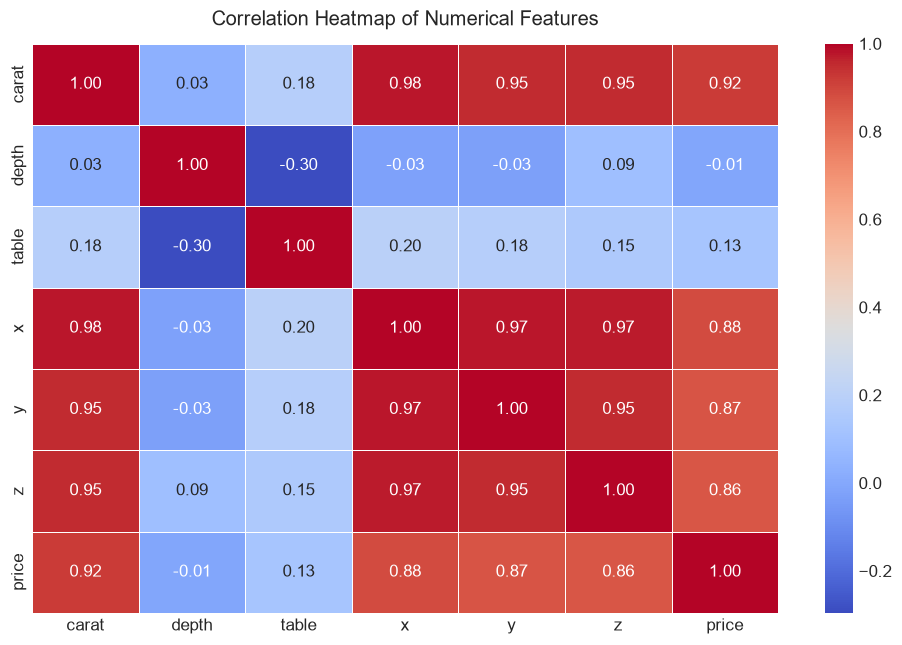

In [9]:
# Correlation heatmap for numerical features
plt.figure(figsize=(9, 6))

corr_matrix = df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

**Observations on Correlation:**
- `carat` has the strongest correlation with `price` (0.92), followed by dimensions `x` (0.88), `y` (0.87), and `z` (0.86).
- `carat`, `x`, `y`, and `z` are very strongly correlated with each other (> 0.95). This makes sense physically because carat is mass, and mass depends on volume (x * y * z).
- `depth` (-0.01) and `table` (0.13) have very low linear correlation with price.

## 2.4 Scatter Plots: Key Features vs Price
Looking at how price changes with carat weight and diamond length.

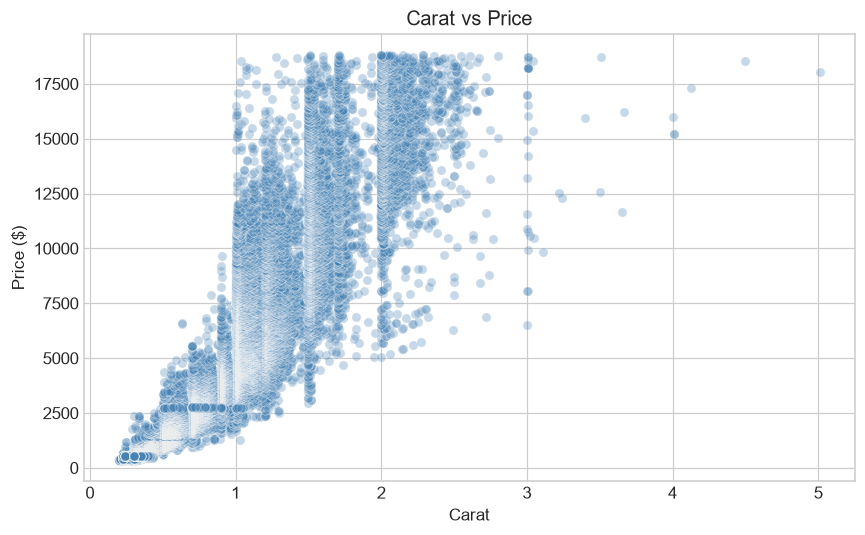

In [10]:
# Scatter plot: Carat vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.3, color='steelblue')
plt.title('Carat vs Price', fontsize=13)
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:**
Carat shows a strong positive relationship with price. As carat increases, the price generally increases. The relationship curves upward, meaning price grows faster than carat weight.

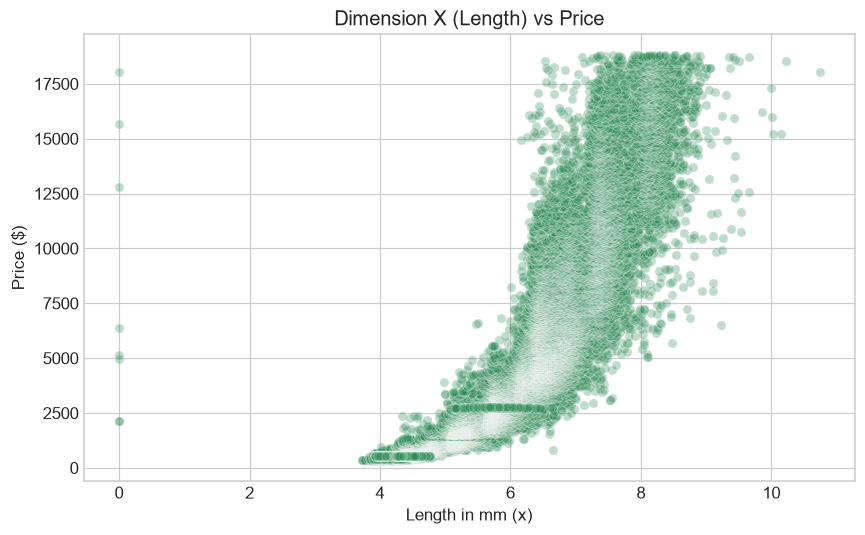

In [11]:
# Scatter plot: Dimension X vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='x', y='price', alpha=0.3, color='seagreen')
plt.title('Dimension X (Length) vs Price', fontsize=13)
plt.xlabel('Length in mm (x)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:**
Dimension `x` (length) also shows a strong positive trend with price. We can also notice a few points at x = 0, which look like unrecorded measurements.

## 2.5 Price Across Categorical Features
Using boxplots to see how price varies with cut, color, and clarity.

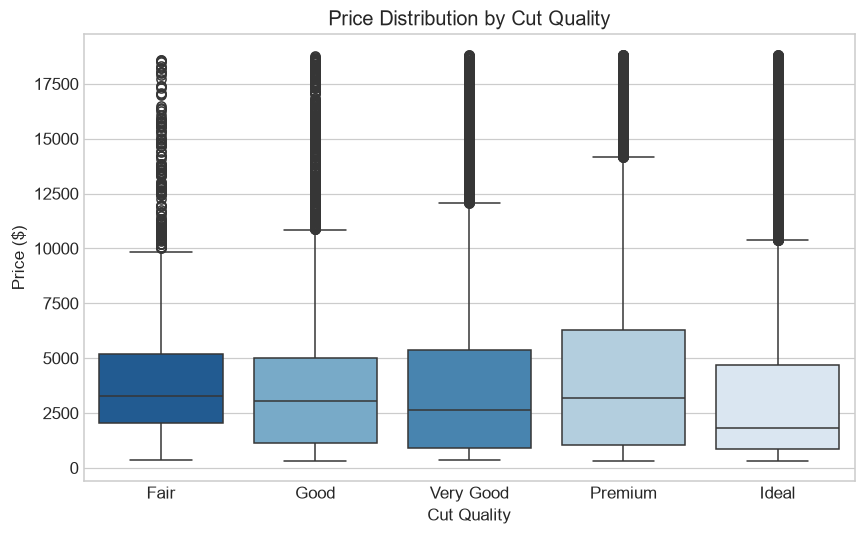

In [12]:
# Boxplot: Cut vs Price
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='cut', y='price', order=cut_order, hue='cut', palette='Blues', legend=False)
plt.title('Price Distribution by Cut Quality', fontsize=13)
plt.xlabel('Cut Quality')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:**
Price varies across cut qualities. Premium and Fair cuts have slightly higher median prices in this raw view, mainly because larger diamonds in this dataset happen to have those cuts.

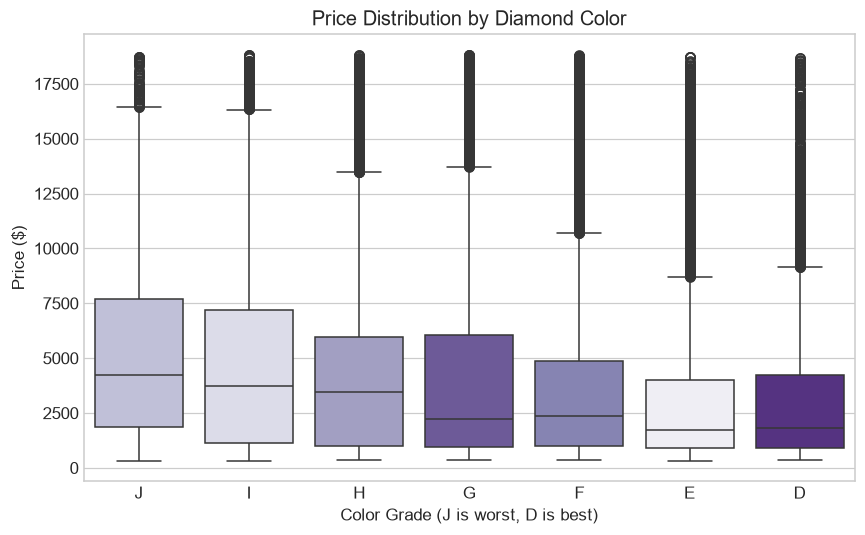

In [13]:
# Boxplot: Color vs Price
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='color', y='price', order=color_order, hue='color', palette='Purples', legend=False)
plt.title('Price Distribution by Diamond Color', fontsize=13)
plt.xlabel('Color Grade (J is worst, D is best)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:**
Lower color grades (like J and I) show higher median prices in this raw view. This is because larger diamonds in the dataset often have lower color ratings.

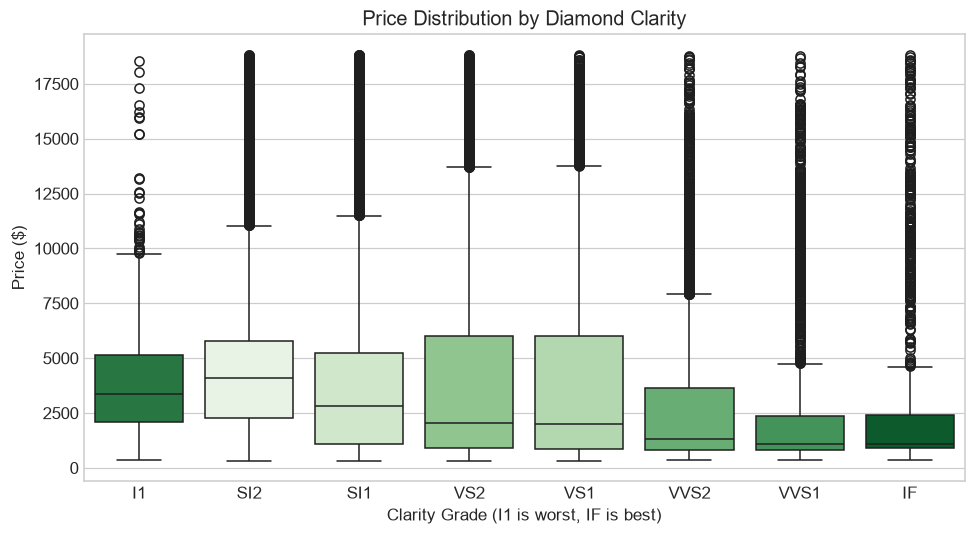

In [14]:
# Boxplot: Clarity vs Price
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='clarity', y='price', order=clarity_order, hue='clarity', palette='Greens', legend=False)
plt.title('Price Distribution by Diamond Clarity', fontsize=13)
plt.xlabel('Clarity Grade (I1 is worst, IF is best)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:**
Similarly for clarity, IF (internally flawless) diamonds do not have the highest median price here because most IF diamonds in the dataset are smaller in carat.

## 2.6 Outlier Inspection
Using boxplots to visually inspect the numerical variables for unusual values without modifying any data yet.

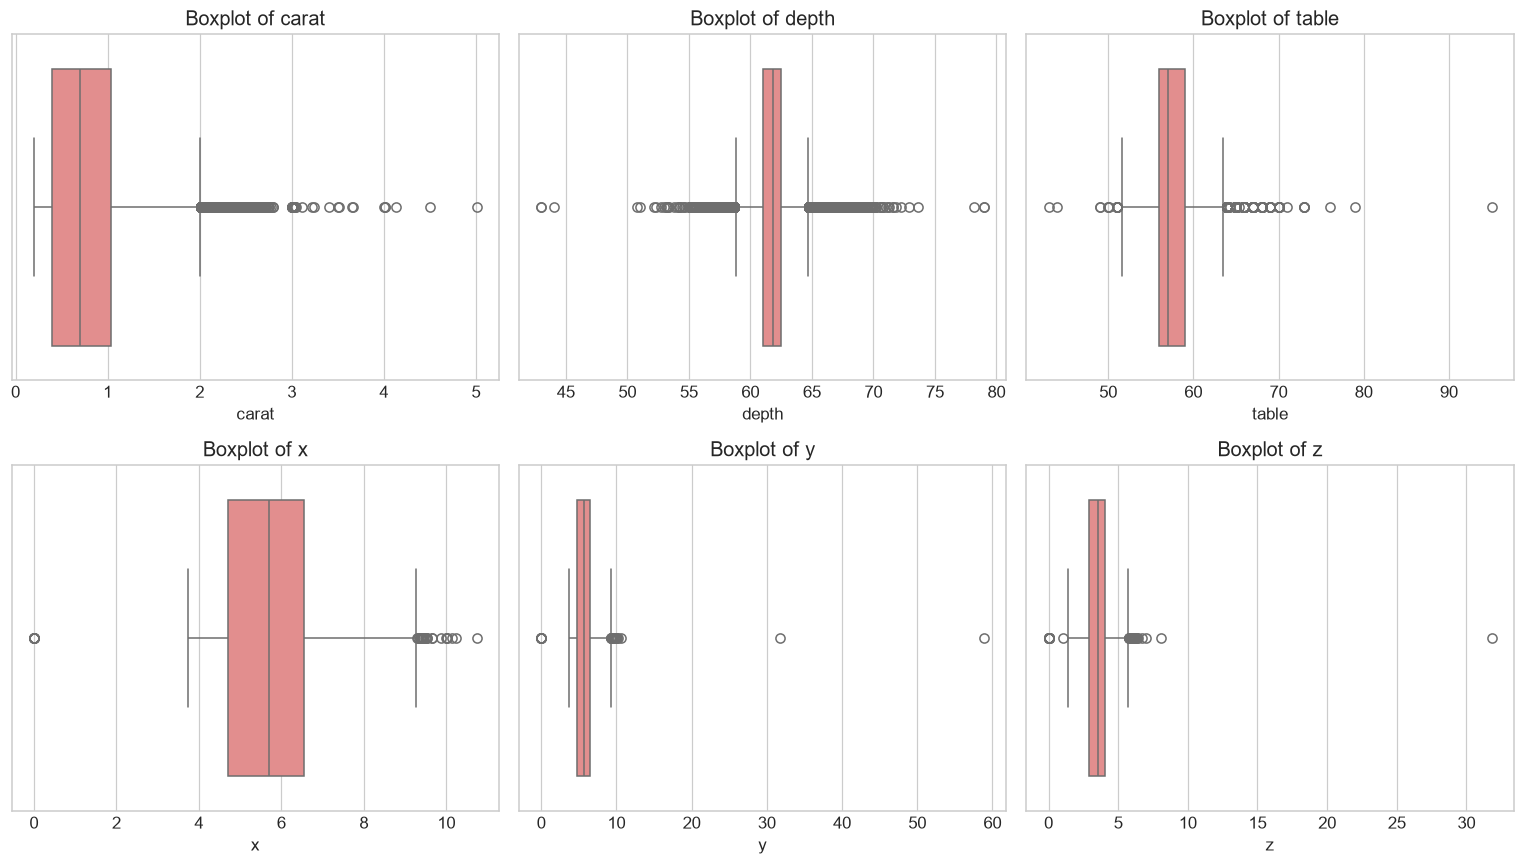

In [15]:
# Boxplots for numerical variables
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Observations on Outliers:**
- `carat`: A few diamonds above 3 carats appear as high values, but these are valid large diamonds.
- `depth` and `table`: Outliers appear on both high and low ends outside typical commercial cut ranges.
- `x`, `y`, `z`: Clear anomalies exist. There are 0 values in all three dimensions, and `y` and `z` have extreme points above 30 mm and 50 mm that look like data entry mistakes. We will clean these in the next milestone.

## 2.7 EDA Summary

- **Price:** Right-skewed distribution with most diamonds priced below $2,500 and a long tail extending up to $18,823.
- **Strongest Predictor:** `carat` has the strongest relationship with price ($r = 0.92$), showing an upward curving non-linear pattern.
- **Dimensions:** Dimensions `x`, `y`, and `z` are strongly correlated with price and with carat weight.
- **Categorical Factors:** Diamond prices vary across cut, color, and clarity, though in raw boxplots the trends are masked by differences in carat weight.
- **Data Quality:** Boxplots confirmed zero values for dimensions and extreme outliers (y > 30 mm, z > 30 mm) that need cleaning.

# 3. Data Cleaning

In this section, we clean the dataset based on the issues identified during the audit and EDA:
1. **Duplicate Records:** Check and remove exact duplicate rows to prevent train/test contamination.
2. **Invalid Dimensions:** Remove rows with non-physical measurements ($x \le 0$, $y \le 0$, $z \le 0$).
3. **Data Entry Errors:** Remove obvious typographical errors in dimensions ($y > 20\text{ mm}$ and $z > 20\text{ mm}$).
4. **Outlier Assessment:** Evaluate statistical outliers (IQR method) and explain why legitimate high-end diamonds are retained.
5. **Missing Values:** Verify completeness and confirm no imputation is needed.
6. **Save Cleaned Data:** Export the cleaned dataset to `datasets/diamonds_cleaned.csv`.

## 3.1 Removing Duplicate Rows
First, we check and remove exact duplicate rows. Duplicate records can cause the exact same diamond to appear in both the training and test sets, leading to overly optimistic evaluation metrics.

In [16]:
# Check duplicates
df_cleaned = df.copy()

duplicates_before = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows before cleaning: {duplicates_before}")

# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)
duplicates_after = df_cleaned.duplicated().sum()

print(f"Number of duplicate rows after cleaning: {duplicates_after}")
print(f"Rows remaining: {len(df_cleaned):,}")

Number of duplicate rows before cleaning: 146
Number of duplicate rows after cleaning: 0
Rows remaining: 53,794


## 3.2 Handling Invalid Dimension Values ($x, y, z \le 0$)
A real physical 3D diamond cannot have a length, width, or depth of 0 mm. These records represent unrecorded sensor dropouts or measurement errors, so we filter them out.

In [17]:
# Identify rows where any physical dimension is <= 0
zero_dims = df_cleaned[(df_cleaned['x'] <= 0) | (df_cleaned['y'] <= 0) | (df_cleaned['z'] <= 0)]
print(f"Rows with x, y, or z <= 0: {len(zero_dims)}")

# Remove invalid zero-dimension records
df_cleaned = df_cleaned[(df_cleaned['x'] > 0) & (df_cleaned['y'] > 0) & (df_cleaned['z'] > 0)].reset_index(drop=True)
print(f"Rows remaining after removing zero dimensions: {len(df_cleaned):,}")

Rows with x, y, or z <= 0: 19
Rows remaining after removing zero dimensions: 53,775


## 3.3 Removing Dimension Typo Errors ($y > 20\text{ mm}$, $z > 20\text{ mm}$)
During the audit, we found a small number of severe data entry errors where width or depth was typed as 31.8 mm or 58.9 mm for normal-sized diamonds. We remove these clear mistakes while keeping all legitimate diamonds.

In [18]:
# Identify extreme dimensional typos
typo_rows = df_cleaned[(df_cleaned['y'] > 20) | (df_cleaned['z'] > 20)]
print(f"Extreme dimension typo rows found: {len(typo_rows)}")
display(typo_rows[['carat', 'cut', 'x', 'y', 'z', 'price']])

# Remove typo records
df_cleaned = df_cleaned[(df_cleaned['y'] < 20) & (df_cleaned['z'] < 20)].reset_index(drop=True)
print(f"\nRows remaining after removing extreme typo rows: {len(df_cleaned):,}")

Extreme dimension typo rows found: 3


,carat,cut,x,y,z,price
24003,2.00,Premium,8.09,58.90,8.06,12210
48251,0.51,Very Good,5.12,5.15,31.80,1970
49030,0.51,Ideal,5.15,31.80,5.12,2075



Rows remaining after removing extreme typo rows: 53,772


## 3.4 Outlier Analysis (IQR Method)
We calculate the Interquartile Range (IQR) for each numerical column to inspect statistical outliers ($< Q_1 - 1.5 \times \text{IQR}$ or $> Q_3 + 1.5 \times \text{IQR}$).

In [19]:
# Outlier inspection using IQR
outlier_summary = []

for col in ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']:
    q1 = df_cleaned[col].quantile(0.25)
    q3 = df_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    pct = (count / len(df_cleaned)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': count,
        'Percentage (%)': round(pct, 2)
    })

display(pd.DataFrame(outlier_summary))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage (%)
0,carat,0.40,1.04,0.64,-0.56,2.00,1867,3.47
1,depth,61.00,62.50,1.50,58.75,64.75,2523,4.69
2,table,56.00,59.00,3.00,51.50,63.50,603,1.12
3,x,4.71,6.54,1.83,1.96,9.28,24,0.04
4,y,4.72,6.54,1.82,1.99,9.27,20,0.04
5,z,2.91,4.03,1.12,1.23,5.71,27,0.05
6,price,951.00,5324.00,4373.00,-5608.50,11883.50,3519,6.54


**Outlier Justification & Decision:**
- **Statistical Outliers vs. Data Quality Defects:** Columns like `carat` (1,867 values > 2.0 ct) and `price` (3,519 values > $11,883) have statistical outliers because the market distribution is naturally right-skewed. Large, high-value diamonds are real, valid commercial items. Removing them would artificially truncate the data and prevent our models from learning to price valuable diamonds.
- **Action Taken:** We retain all legitimate statistical outliers in `carat`, `depth`, `table`, and `price`. We only removed the genuine data-quality defects (zero dimensions and extreme typographical errors).

## 3.5 Checking Missing Values
We verify whether any missing values exist in the cleaned data.

In [20]:
# Verify missing values and final shape
missing_counts = df_cleaned.isnull().sum()
print("Missing values in cleaned dataset:")
print(missing_counts)
print(f"\nTotal Missing Values: {missing_counts.sum()}")
print(f"Final Cleaned Dataset Shape: {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")

Missing values in cleaned dataset:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

Total Missing Values: 0
Final Cleaned Dataset Shape: 53,772 rows x 10 columns


**Observation on Missing Values:**
The dataset has 0 missing values across all columns. Therefore, no imputation is needed.

# 4. Feature Engineering

In this section, we create a new feature to help the regression models better capture the overall physical size of each diamond:
- **`volume`**: Calculated as $\text{volume} = x \times y \times z$ (length $\times$ width $\times$ depth in $\text{mm}^3$).

> Volume combines the diamond's length, width, and depth into one measurement of its approximate physical size. This may help the regression models capture the effect of overall diamond size on price.

## 4.1 Creating the Volume Feature
Calculating bounding volume from the three physical millimeter dimensions ($x \times y \times z$).

In [21]:
# Create volume feature from physical dimensions
df_cleaned['volume'] = df_cleaned['x'] * df_cleaned['y'] * df_cleaned['z']

# Display sample rows showing dimensions, volume, and price
print("Sample rows with newly engineered volume feature:")
display(df_cleaned[['x', 'y', 'z', 'volume', 'price']].head())

Sample rows with newly engineered volume feature:


,x,y,z,volume,price
0,3.95,3.98,2.43,38.202030,326
1,3.89,3.84,2.31,34.505856,326
2,4.05,4.07,2.31,38.076885,327
3,4.20,4.23,2.63,46.724580,334
4,4.34,4.35,2.75,51.917250,335


In [22]:
# Check summary statistics and missing values for volume
volume_stats = pd.DataFrame({
    'Metric': ['Minimum Volume', 'Maximum Volume', 'Mean Volume', 'Missing Values'],
    'Value': [
        f"{df_cleaned['volume'].min():.2f} mm³",
        f"{df_cleaned['volume'].max():.2f} mm³",
        f"{df_cleaned['volume'].mean():.2f} mm³",
        f"{df_cleaned['volume'].isnull().sum()}"
    ]
})

display(volume_stats)

,Metric,Value
0,Minimum Volume,31.71 mm³
1,Maximum Volume,790.13 mm³
2,Mean Volume,129.78 mm³
3,Missing Values,0


## 4.2 Volume vs Price Relationship
Scatter plot inspecting how the newly engineered volume feature relates to diamond price.

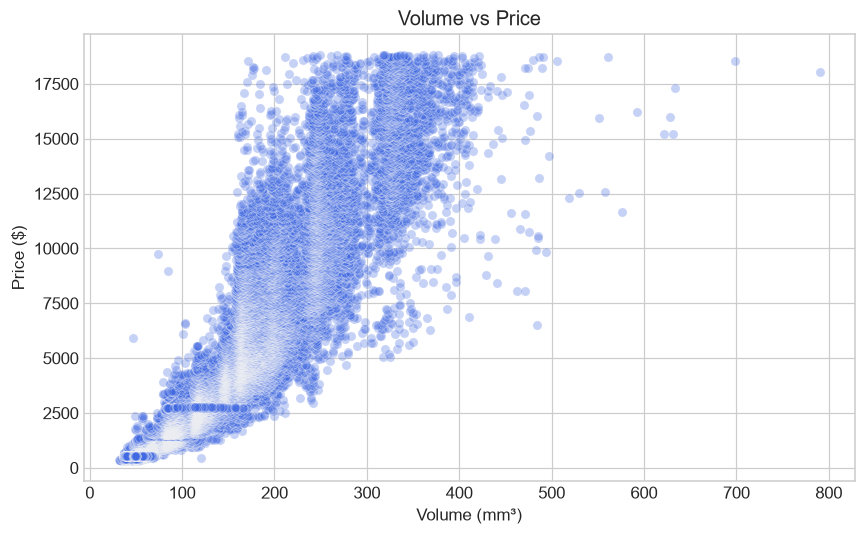

In [23]:
# Scatter plot: Volume vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cleaned, x='volume', y='price', alpha=0.3, color='royalblue')
plt.title('Volume vs Price', fontsize=13)
plt.xlabel('Volume (mm³)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation on Volume:**
Volume shows a strong positive relationship with price, very similar to carat weight. As diamond volume increases, the price increases non-linearly, showing that physical volume is a strong predictive feature for regression.

# 5. Preprocessing

In this section, we prepare the data for regression modeling:
1. **Define Features and Target:** Separate input predictors ($X$) from the target price ($y$).
2. **Train/Test Split:** 80% training data and 20% test data with price-stratification and `random_state=42`.
3. **Categorical Encoding:** Ordinal encoding for `cut`, `color`, and `clarity` preserving natural quality orders.
4. **Numerical Scaling:** Standard scaling for numerical features (`carat`, `depth`, `table`, `x`, `y`, `z`).
5. **Leakage-Free Transformation:** Fitting preprocessing **only** on the training data.
6. **Data Checks:** Compare train and test price distributions to confirm stratification.

## 5.1 Defining Input Features and Target
We separate the 9 input features ($X$) from the target column ($y = \text{price}$)।

In [24]:
# Separate features and target
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (53772, 10)
Target (y) shape: (53772,)


## 5.2 Splitting into Train and Test Sets (80:20)
We perform an 80:20 train/test split. Because `price` is a continuous variable, we create 5 simple quantile price bins to stratify the split so that both sets have a balanced representation across the price range.

In [25]:
from sklearn.model_selection import train_test_split

# Create 5 price bins for stratified splitting
price_bins = pd.qcut(y, q=5, labels=False)

# 80:20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=price_bins
)

print(f"Training set: X_train = {X_train.shape[0]:,} rows, y_train = {y_train.shape[0]:,} rows")
print(f"Testing set:  X_test  = {X_test.shape[0]:,} rows, y_test  = {y_test.shape[0]:,} rows")

Training set: X_train = 43,017 rows, y_train = 43,017 rows
Testing set:  X_test  = 10,755 rows, y_test  = 10,755 rows


**Why Train/Test Split is Needed:**
We evaluate machine learning models on a separate test set to assess how well they generalize to new, unseen diamonds. Training and evaluating on the same data would give an unrealistically optimistic impression of performance (overfitting).

## 5.3 Setting Up Encoding and Scaling
- **Categorical Features (`cut`, `color`, `clarity`):** We use `OrdinalEncoder` with explicit domain ordering matching official gemological standards:
  - `cut`: Fair < Good < Very Good < Premium < Ideal
  - `color`: J (worst) < I < H < G < F < E < D (best)
  - `clarity`: I1 (worst) < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF (best)
- **Numerical Features (`carat`, `depth`, `table`, `x`, `y`, `z`, `volume`):** We apply `StandardScaler` to standardize values to mean 0 and standard deviation 1.

In [26]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
cat_cols = ['cut', 'color', 'clarity']

# Define natural diamond grading orders
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), cat_cols)
    ]
)

**Why Encoding and Scaling are Used:**
- **Encoding:** Machine learning algorithms perform numerical operations and cannot directly process text labels. Ordinal encoding preserves the natural hierarchy in diamond grades without creating excessive sparse columns.
- **Scaling:** Features have very different scales (e.g. `carat` ranges from 0.2 to 5.0, while `depth` is around 60%). Distance-based and regularized algorithms like Ridge, Lasso, KNN, and SVR require standardized features so larger-scale features do not dominate the objective function.

## 5.4 Fitting Preprocessing Only on Training Data
To prevent **data leakage**, the encoder and scaler are fitted **strictly on the training data (`X_train`)**. The learned parameters (means, standard deviations, categories) are then used to transform both the training and test sets.

In [27]:
# Fit preprocessor ONLY on training data
preprocessor.fit(X_train)

# Transform both training and test data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame with clean column names for inspection
feature_names = num_cols + cat_cols
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print("\nFirst 5 rows of preprocessed training data:")
display(X_train_df.head())

X_train_processed shape: (43017, 10)
X_test_processed shape:  (10755, 10)

First 5 rows of preprocessed training data:


,carat,depth,table,x,y,z,volume,cut,color,clarity
23969,-0.841130,0.319025,-1.551681,-0.905354,-0.877497,-0.853079,-0.832566,4.0,0.0,4.0
21130,2.041697,0.878640,2.491212,1.719047,1.711639,1.842675,1.984396,2.0,2.0,2.0
52862,-0.162817,-0.100686,-0.204050,-0.000697,0.024641,0.002026,-0.168529,4.0,1.0,5.0
31728,-0.968313,0.668785,0.694371,-1.183021,-1.175203,-1.113958,-0.992311,2.0,5.0,5.0
9817,0.536692,-0.590349,-0.653260,0.814390,0.746351,0.697704,0.596759,4.0,4.0,1.0


**Why Fitting Only on Training Data Avoids Data Leakage:**
Fitting scalers or encoders on the entire dataset would allow statistical information from the test set (such as the overall mean and variance) to bleed into the model's training stage. This is a form of data leakage that leads to overly optimistic test metrics that do not hold in real-world deployment.

## 5.5 Checking Stratification of Price in Train and Test Sets
We compare summary statistics between `y_train` and `y_test` to confirm that the price distributions are well-matched.

In [28]:
# Compare train and test price distributions
split_comparison = pd.DataFrame({
    'Metric': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Q1 (25%)', 'Q3 (75%)'],
    'Train Set (y_train)': [
        f"{len(y_train):,}",
        f"${y_train.mean():,.2f}",
        f"${y_train.median():,.2f}",
        f"${y_train.std():,.2f}",
        f"${y_train.min():,}",
        f"${y_train.max():,}",
        f"${y_train.quantile(0.25):,.2f}",
        f"${y_train.quantile(0.75):,.2f}"
    ],
    'Test Set (y_test)': [
        f"{len(y_test):,}",
        f"${y_test.mean():,.2f}",
        f"${y_test.median():,.2f}",
        f"${y_test.std():,.2f}",
        f"${y_test.min():,}",
        f"${y_test.max():,}",
        f"${y_test.quantile(0.25):,.2f}",
        f"${y_test.quantile(0.75):,.2f}"
    ]
})

display(split_comparison)

,Metric,Train Set (y_train),Test Set (y_test)
0,Count,"43,017","10,755"
1,Mean,"$3,924.79","$3,956.54"
2,Median,"$2,400.00","$2,407.00"
3,Std Dev,"$3,971.14","$4,044.26"
4,Min,$326,$326
5,Max,"$18,823","$18,797"
6,Q1 (25%),$954.00,$943.50
7,Q3 (75%),"$5,330.00","$5,311.50"


**Observation on Stratification:**
The mean, median, standard deviation, and quartiles of `y_train` and `y_test` are nearly identical (median of $2,400 in train vs. $2,407 in test; mean of $3,925 in train vs. $3,957 in test). This confirms that stratified splitting successfully preserved the target distribution across both partitions.

# 6. Linear Regression

> Linear Regression predicts diamond price by learning the linear relationship between the input features and price.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Display evaluation metrics
lr_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_lr:.4f}", f"${rmse_lr:,.2f}", f"${mae_lr:,.2f}"]
})

print("Linear Regression Model Performance:")
display(lr_results)

Linear Regression Model Performance:


,Metric,Value
0,R² Score,0.9093
1,Root Mean Squared Error (RMSE),"$1,217.74"
2,Mean Absolute Error (MAE),$797.70


> **Observation on Linear Regression:**  
> The baseline Linear Regression model achieves an $R^2$ score of **0.9093**, indicating that approximately **90.93%** of the variance in diamond prices is explained by the linear combination of the preprocessed features. The model yields an RMSE of **$1,217.74** and an MAE of **$797.70**. While performance is strong, non-linear relationships observed during EDA suggest that tree-based or regularized models may further refine price estimates.

# 7. Ridge Regression

> Ridge Regression is a linear regression method that adds L2 regularization to reduce the effect of large coefficients and help with multicollinearity.

In [30]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Ridge Regression model (alpha=1.0)
ridge_model = Ridge()
ridge_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_ridge = ridge_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# Display evaluation metrics
ridge_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_ridge:.4f}", f"${rmse_ridge:,.2f}", f"${mae_ridge:,.2f}"]
})

print("Ridge Regression Model Performance:")
display(ridge_results)

Ridge Regression Model Performance:


,Metric,Value
0,R² Score,0.9093
1,Root Mean Squared Error (RMSE),"$1,217.70"
2,Mean Absolute Error (MAE),$797.76


> **Observation:**
> - **Almost Identical Performance:** Ridge Regression gives nearly the exact same results as Linear Regression, with an $R^2$ score of **0.9093** and an average error (MAE) of about **$798**.
> - **Why this happens:** The linear pattern between diamond size/quality and price is already quite strong, so applying a small L2 penalty doesn't change the predictions by much.
> - **Main Benefit:** Even though the score is the same, Ridge is a safer and more stable model because it prevents any single feature from having an overly large weight, which helps when features like `carat`, `volume`, and millimeter dimensions ($x, y, z$) are closely linked to each other.

# 8. Lasso Regression

> Lasso Regression is a linear regression method that uses L1 regularization. It can reduce the effect of less useful features by shrinking some coefficients toward zero.

In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Lasso Regression model
lasso_model = Lasso(max_iter=2000, tol=0.01, random_state=42)
lasso_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_lasso = lasso_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# Display evaluation metrics
lasso_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_lasso:.4f}", f"${rmse_lasso:,.2f}", f"${mae_lasso:,.2f}"]
})

print("Lasso Regression Model Performance:")
display(lasso_results)

Lasso Regression Model Performance:


,Metric,Value
0,R² Score,0.9091
1,Root Mean Squared Error (RMSE),"$1,219.03"
2,Mean Absolute Error (MAE),$799.20


> **Observation:**
> - **Consistent Performance:** Lasso Regression achieves an $R^2$ score of **0.9091**, an RMSE of **$1,219.03**, and an MAE of **$799.20**, which is practically identical to both Linear Regression ($R^2 = 0.9093$) and Ridge Regression ($R^2 = 0.9093$).
> - **How it differs from Ridge:** While Ridge (L2) shrinks coefficients close to zero, Lasso (L1) can shrink less useful coefficients all the way to zero, functioning as automatic feature selection.
> - **Key Takeaway:** Because all 10 features (especially carat, dimensions, cut, color, clarity, and volume) are genuinely relevant for determining diamond market prices, the model preserves them all and achieves consistent ~90.9% explanatory power.

# 9. ElasticNet Regression

> ElasticNet Regression combines L1 and L2 regularization. It helps control large coefficients while also reducing the effect of less useful features.

In [32]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default ElasticNet Regression model
elastic_net_model = ElasticNet(random_state=42)
elastic_net_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_elastic_net = elastic_net_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)
rmse_elastic_net = np.sqrt(mean_squared_error(y_test, y_pred_elastic_net))
mae_elastic_net = mean_absolute_error(y_test, y_pred_elastic_net)

# Display evaluation metrics
elastic_net_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_elastic_net:.4f}", f"${rmse_elastic_net:,.2f}", f"${mae_elastic_net:,.2f}"]
})

print("ElasticNet Regression Model Performance:")
display(elastic_net_results)

ElasticNet Regression Model Performance:


,Metric,Value
0,R² Score,0.8647
1,Root Mean Squared Error (RMSE),"$1,487.62"
2,Mean Absolute Error (MAE),"$1,008.65"


> **Observation:**
> - **Comparison with Previous Models:** With default parameters ($\alpha=1.0$, $\text{l1\_ratio}=0.5$), ElasticNet achieves an $R^2$ score of **0.8647**, an RMSE of **$1,487.62**, and an MAE of **$1,008.65$**. This is slightly lower than Linear Regression ($R^2 = 0.9093$), Ridge ($R^2 = 0.9093$), and Lasso ($R^2 = 0.9091$).
> - **Why this happens:** ElasticNet combines both L1 and L2 penalties simultaneously. Under default settings ($\alpha=1.0$), this dual penalty applies stronger shrinkage to the feature weights than Ridge or Lasso alone, introducing a bit more bias and slight underfitting.
> - **Key Takeaway:** ElasticNet is especially powerful when dealing with multiple correlated features because it groups them together instead of picking just one like Lasso might. To match the ~91% accuracy of the other models on this dataset, the regularization strength $\alpha$ would simply need to be tuned to a smaller value.

# 10. Polynomial Regression

> Polynomial Regression extends Linear Regression by adding polynomial terms so the model can capture non-linear relationships between features and diamond price.

In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Create polynomial features (degree=2) - fit ONLY on training data
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

# Initialize and train Linear Regression on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on transformed test set
y_pred_poly = poly_model.predict(X_test_poly)

# Calculate evaluation metrics
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

# Display evaluation metrics
poly_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_poly:.4f}", f"${rmse_poly:,.2f}", f"${mae_poly:,.2f}"]
})

print("Polynomial Regression (Degree 2) Model Performance:")
display(poly_results)

Polynomial Regression (Degree 2) Model Performance:


,Metric,Value
0,R² Score,0.9642
1,Root Mean Squared Error (RMSE),$765.52
2,Mean Absolute Error (MAE),$453.21


> **Observation:**
> - **Significant Improvement:** Polynomial Regression (degree 2) achieves an $R^2$ score of **0.9642**, an RMSE of **$765.52**, and an MAE of **$453.21$**. This is a major jump over baseline Linear Regression ($R^2 = 0.9093$, MAE = $797.70$).
> - **Why it performs so much better:** During our EDA, we noticed that diamond price does not increase in a straight line with carat weight - it curves upward exponentially. By creating squared terms (like $\text{carat}^2$) and interaction terms between features, Polynomial Regression captures this natural curvature.
> - **Error Reduction:** Average prediction error (MAE) is cut down from ~$798 to ~$453, showing that modeling non-linear terms is essential for accurate diamond valuation.

# 11. Decision Tree Regressor

> Decision Tree Regression predicts diamond price by splitting the data into smaller groups based on feature values and making predictions from the resulting groups.

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

# Display evaluation metrics
dt_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_dt:.4f}", f"${rmse_dt:,.2f}", f"${mae_dt:,.2f}"]
})

print("Decision Tree Regressor Model Performance:")
display(dt_results)

Decision Tree Regressor Model Performance:


,Metric,Value
0,R² Score,0.9661
1,Root Mean Squared Error (RMSE),$745.08
2,Mean Absolute Error (MAE),$360.01


> **Observation:**
> - **Top Performance So Far:** Decision Tree Regressor achieves an $R^2$ score of **0.9661**, an RMSE of **$745.08**, and an MAE of **$360.01$**, outperforming all previous models including Polynomial Regression ($R^2 = 0.9642$, MAE = $453.21$) and Linear Regression ($R^2 = 0.9093$, MAE = $797.70$).
> - **Why it works so well:** Unlike linear models that try to fit a single equation across the entire dataset, a decision tree splits the diamond data into specific sub-regions (like high-carat stones with ideal cut vs. low-carat stones with poor clarity). This allows it to capture sharp price jumps and complex non-linear feature interactions naturally.
> - **Lowest Error:** Average prediction error (MAE) drops dramatically to ~$360, more than cutting in half the baseline linear regression error (~$798).

# 12. Random Forest Regressor

> Random Forest Regression combines many decision trees and averages their predictions to produce a more stable price prediction.

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Display evaluation metrics
rf_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_rf:.4f}", f"${rmse_rf:,.2f}", f"${mae_rf:,.2f}"]
})

print("Random Forest Regressor Model Performance:")
display(rf_results)

Random Forest Regressor Model Performance:


,Metric,Value
0,R² Score,0.9810
1,Root Mean Squared Error (RMSE),$557.43
2,Mean Absolute Error (MAE),$270.00


> **Observation:**
> - **Best Performance Yet:** Random Forest Regressor sets a new benchmark with an $R^2$ score of **0.9810**, an RMSE of **$557.43**, and an MAE of **$270.00$**. It clearly outperforms both individual Decision Trees ($R^2 = 0.9661$, MAE = $360.01$) and linear/polynomial baselines.
> - **Power of Ensembling:** A single decision tree can be noisy and prone to overfitting on training quirks. By training an ensemble of 100 decision trees on random subsets of data and features and averaging their outputs, Random Forest smooths out high variance and makes much more reliable predictions.
> - **Real-World Impact:** The average error drops to just ~$270 on diamonds averaging nearly $4,000, achieving high precision across both budget and luxury stones.

# 13. Gradient Boosting Regressor

> Gradient Boosting Regressor builds decision trees one after another, with each new tree trying to reduce the errors made by the previous trees.

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_gbr = gbr_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_gbr = r2_score(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# Display evaluation metrics
gbr_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_gbr:.4f}", f"${rmse_gbr:,.2f}", f"${mae_gbr:,.2f}"]
})

print("Gradient Boosting Regressor Model Performance:")
display(gbr_results)

Gradient Boosting Regressor Model Performance:


,Metric,Value
0,R² Score,0.9755
1,Root Mean Squared Error (RMSE),$632.82
2,Mean Absolute Error (MAE),$349.89


> **Observation:**
> - **Strong Ensemble Performance:** Gradient Boosting Regressor achieves an $R^2$ score of **0.9755**, an RMSE of **$632.82**, and an MAE of **$349.89$**. It comfortably outperforms single Decision Trees ($R^2 = 0.9661$, MAE = $360.01$) and all linear/polynomial models.
> - **How it differs from Random Forest:** While Random Forest trains trees independently in parallel and averages them, Gradient Boosting trains trees sequentially in a chain. Each new tree specifically focuses on correcting the residual errors made by the previous trees.
> - **Comparison:** Random Forest remains the top performer with $R^2 = 0.9810$ and MAE = $270.00$, but default Gradient Boosting is close behind with a very low MAE of ~$350, demonstrating the power of sequential boosting.

# 14. Support Vector Regressor (SVR)

> SVR uses a support vector machine approach for regression. It tries to fit the data within a small error margin while controlling model complexity.

In [37]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize and train default Support Vector Regressor
svr_model = SVR()
svr_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_svr = svr_model.predict(X_test_processed)

# Calculate evaluation metrics
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

# Display evaluation metrics
svr_results = pd.DataFrame({
    'Metric': ['R² Score', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{r2_svr:.4f}", f"${rmse_svr:,.2f}", f"${mae_svr:,.2f}"]
})

print("Support Vector Regressor (SVR) Model Performance:")
display(svr_results)

Support Vector Regressor (SVR) Model Performance:


,Metric,Value
0,R² Score,0.6015
1,Root Mean Squared Error (RMSE),"$2,552.78"
2,Mean Absolute Error (MAE),"$1,220.11"


> **Observation:**
> - **Performance Overview:** With default parameters ($C=1.0, \epsilon=0.1$), Support Vector Regressor achieves an $R^2$ score of **0.6015**, an RMSE of **$2,552.78**, and an MAE of **$1,220.11$**.
> - **Why default SVR underperforms here:** In scikit-learn, SVR defaults to $C=1.0$. Because diamond prices span thousands of dollars (ranging up to $18,800), a penalty parameter of $C=1.0$ is far too small to punish large errors, causing the model to severely underfit.
> - **Comparison with Other Models:** Tree-based models (Random Forest with $R^2 = 0.9810$, Gradient Boosting with $R^2 = 0.9755$) and even baseline linear models ($R^2 \approx 0.909$) perform significantly better out of the box. For SVR to compete on large-scale pricing data, hyperparameter tuning of $C$ or scaling the target variable would be required.